In [11]:
# Step 1: Read input data.

from __future__ import annotations

from pathlib import Path
import matplotlib as mpl
import numpy as np
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import lru_cache
from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

def load_crosswalk(url: str, source: str):
    df = pd.read_csv(url, skiprows=10)
    df["source"] = source
    return df

@lru_cache(maxsize=None)
def get_label(uberon_id):
    iri = f'http://purl.obolibrary.org/obo/{uberon_id.replace(":", "_")}'
    url = "https://www.ebi.ac.uk/ols4/api/ontologies/uberon/terms"
    resp = requests.get(url, params={"iri": iri}, timeout=30)
    if resp.status_code == 200 and resp.json()["_embedded"]["terms"]:
        return resp.json()["_embedded"]["terms"][0]["label"]
    return None

LOCAL_CROSSWALKS = {
    "azimuth": "https://cdn.humanatlas.io/digital-objects/ctann/azimuth/v1.4/assets/azimuth-crosswalk.csv",
    "celltypist": "https://cdn.humanatlas.io/digital-objects/ctann/celltypist/v1.3/assets/celltypist-crosswalk.csv",
    "deepcelltypes": "https://cdn.humanatlas.io/digital-objects/ctann/deepcelltypes/v1.2/assets/deepcelltypes-crosswalk.csv",
    "deepcelltypes_hubmap": "https://cdn.humanatlas.io/digital-objects/ctann/deepcelltypes-hubmap/v1.2/assets/deepcelltypes-hubmap-crosswalk.csv",
    "frmatch": "https://cdn.humanatlas.io/digital-objects/ctann/frmatch/v1.0/assets/frmatch-crosswalk.csv",
    "pan_human_azimuth": "https://cdn.humanatlas.io/digital-objects/ctann/pan-human-azimuth/v1.2/assets/pan-human-azimuth-crosswalk.csv",
    "popv": "https://cdn.humanatlas.io/digital-objects/ctann/popv/v1.4/assets/popv-crosswalk.csv",
    "ribca": "https://cdn.humanatlas.io/digital-objects/ctann/ribca/v1.0/assets/ribca-crosswalk.csv",
    "stellar": "https://cdn.humanatlas.io/digital-objects/ctann/stellar/v1.0/assets/stellar-crosswalk.csv",
    "vccf": "https://cdn.humanatlas.io/digital-objects/ctann/vccf/v1.2/assets/vccf-crosswalk.csv",
}

SOURCE_LABELS = {
    "azimuth": "Azimuth",
    "celltypist": "CellTypist",
    "deepcelltypes": "DeepCell Types",
    "deepcelltypes_hubmap": "DeepCell Types-HuBMAP",
    "frmatch": "FR-Match",
    "pan_human_azimuth": "Pan-human Azimuth",
    "popv": "popV",
    "ribca": "RIBCA",
    "stellar": "STELLAR",
    "vccf": "CDE Spatial Omics",
}

# Figure / layout settings
SORT_MODE = "alphabetical"  # or "coverage"
FIGURE_FONT_SIZE = 10.5
ROW_SPACING_SCALE = 0.50
BOTTOM_SPACE_SCALE = 1.65
BOTTOM_LEGEND_SPACE_MM = 0
FIGURE_WIDTH_MM = 366.6
ORIGINAL_FIGURE_HEIGHT_MM = 135
ORIGINAL_BOTTOM_FRACTION = 0.39
ORIGINAL_TOP_FRACTION = 0.975
MM_TO_INCH = 1 / 25.4



def load_crosswalk(path: str, source: str) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=10)
    df["source"] = source
    return df


def marker_area(count_like) -> np.ndarray:
    return 6 + 0.42 * np.asarray(count_like, dtype=float)


def format_legend_value(value: float) -> str:
    return f"{value:.0f}" if float(value).is_integer() else f"{value:.1f}"



mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": FIGURE_FONT_SIZE,
    "axes.labelsize": FIGURE_FONT_SIZE,
    "xtick.labelsize": FIGURE_FONT_SIZE,
    "ytick.labelsize": FIGURE_FONT_SIZE,
    "legend.fontsize": FIGURE_FONT_SIZE,
    "legend.title_fontsize": FIGURE_FONT_SIZE,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

print("Loading local crosswalk data...")
df_combined = pd.concat(
    [load_crosswalk(path, source) for source, path in LOCAL_CROSSWALKS.items()],
    ignore_index=True,
)

print(df_combined.head())

Loading local crosswalk data...
  Organ_Level        Organ_ID       Annotation_Label Annotation_Label_ID  \
0    Heart_L2  UBERON:0000948              Adipocyte          AZ:0000001   
1    Heart_L2  UBERON:0000948   Arterial Endothelial          AZ:0000002   
2    Heart_L2  UBERON:0000948   Atrial Cardiomyocyte          AZ:0000003   
3    Heart_L2  UBERON:0000948                      B          AZ:0000004   
4    Heart_L2  UBERON:0000948  Capillary Endothelial          AZ:0000005   

                         CL_Label       CL_ID         CL_Match   source  \
0                       adipocyte  CL:0000136  skos:exactMatch  azimuth   
1      endothelial cell of artery  CL:1000413  skos:exactMatch  azimuth   
2  regular atrial cardiac myocyte  CL:0002129  skos:exactMatch  azimuth   
3                          B cell  CL:0000236  skos:exactMatch  azimuth   
4      capillary endothelial cell  CL:0002144  skos:exactMatch  azimuth   

   Unnamed: 7  
0         NaN  
1         NaN  
2         Na

In [12]:
# Step 2: Get the source data used to create the figure.

df_size = (
    df_combined.groupby(["source", "Organ_ID"], as_index=False)["CL_Label"]
    .nunique()
    .rename(columns={"CL_Label": "n_unique_cell_label"})
)

mapping_keys = [
    "source",
    "Organ_ID",
    "Annotation_Label_ID",
    "CL_ID",
    "CL_Match",
]
df_mappings = df_combined.drop_duplicates(mapping_keys).copy()

df_exact_match_cell_labels = (
    df_mappings.loc[df_mappings["CL_Match"].eq("skos:exactMatch")]
    .groupby(["source", "Organ_ID"], as_index=False)["CL_Label"]
    .nunique()
    .rename(columns={"CL_Label": "n_exact_match_cell_labels"})
)
# Node color is the number of unique cell-type labels with a skos:exactMatch.

df_plot = df_size.merge(
    df_exact_match_cell_labels,
    on=["source", "Organ_ID"],
    how="left",
    validate="one_to_one",
)
df_plot["n_exact_match_cell_labels"] = df_plot["n_exact_match_cell_labels"].fillna(0).astype(int)

df_plot["source"] = df_plot["source"].map(SOURCE_LABELS)
df_plot["source"] = pd.Categorical(
    df_plot["source"],
    categories=list(SOURCE_LABELS.values()),
    ordered=True,
)
# Resolve each identifier once, then reuse its human-readable label for all tools.
organ_labels = {
    organ_id: get_label(organ_id)
    for organ_id in df_plot["Organ_ID"].dropna().unique()
}
df_plot["organ_label"] = df_plot["Organ_ID"].map(organ_labels)
df_plot["organ_label"] = (
    df_plot["organ_label"]
    .fillna("Unspecified")
    .astype(str)
    .replace({"None": "Unspecified", "nan": "Unspecified"})
)
df_plot = df_plot.loc[df_plot["organ_label"] != "Unspecified"].copy()
print(df_plot)

tool_order = [
    label for label in SOURCE_LABELS.values()
    if label in set(df_plot["source"].astype(str))
]

organ_summary = (
    df_plot.groupby("organ_label", observed=True)
    .agg(
        n_tools=("source", "nunique"),
        total_cell_types=("n_unique_cell_label", "sum"),
    )
)

if SORT_MODE == "alphabetical":
    organ_order = sorted(organ_summary.index, key=str.casefold)
elif SORT_MODE == "coverage":
    organ_order = (
        organ_summary
        .sort_values(["n_tools", "total_cell_types"], ascending=[False, False], kind="stable")
        .index
        .tolist()
    )
else:
    raise ValueError("SORT_MODE must be 'alphabetical' or 'coverage'.")

# Keep the existing order of every other organ, but show whole-body coverage first.
if "body proper" in organ_order:
    organ_order = ["body proper"] + [organ for organ in organ_order if organ != "body proper"]

x_position = {organ: i for i, organ in enumerate(organ_order)}
y_position = {tool: i for i, tool in enumerate(tool_order)}

# Source data used by the figure: tools are rows and organs are columns.
match_rate_matrix = (
    df_plot.pivot(index="source", columns="organ_label", values="n_exact_match_cell_labels")
    .reindex(index=tool_order, columns=organ_order)
)
cell_type_matrix = (
    df_plot.pivot(index="source", columns="organ_label", values="n_unique_cell_label")
    .reindex(index=tool_order, columns=organ_order)
)
print("Exact-match cell-type label matrix (unique #Cell types)")
display(match_rate_matrix)
print("Cell type number matrix (unique #Cell types)")
display(cell_type_matrix)

pan_human_raw_labels = df_combined.loc[
    df_combined["source"].eq("pan_human_azimuth"), "CL_Label"
].dropna().astype(str).str.strip()
pan_human_raw_labels = pan_human_raw_labels.loc[pan_human_raw_labels.ne("")]
pan_human_rows = df_plot.loc[df_plot["source"].eq("Pan-human Azimuth")]
print(f"Pan-Human Azimuth unique labels across all rows: {pan_human_raw_labels.nunique()}")
print(f"Pan-Human Azimuth maximum node-size label count: {pan_human_rows['n_unique_cell_label'].max()}")
print(f"Pan-Human Azimuth maximum exact-match label count: {pan_human_rows['n_exact_match_cell_labels'].max()}")



               source        Organ_ID  n_unique_cell_label  \
0             Azimuth  UBERON:0000160                   12   
1             Azimuth  UBERON:0000178                   77   
3             Azimuth  UBERON:0000945                   16   
4             Azimuth  UBERON:0000948                   36   
5             Azimuth  UBERON:0000955                    9   
..                ...             ...                  ...   
73  CDE Spatial Omics  UBERON:0002097                   20   
74  CDE Spatial Omics  UBERON:0002106                   20   
75  CDE Spatial Omics  UBERON:0002371                   49   
76  CDE Spatial Omics  UBERON:0002372                   71   
77  CDE Spatial Omics  UBERON:0002450                   29   

    n_exact_match_cell_labels   organ_label  
0                           3     intestine  
1                          38         blood  
3                           2       stomach  
4                          27         heart  
5                        

organ_label,body proper,adipose tissue,adrenal gland,blood,blood vasculature,bone marrow,brain,decidua,esophagus,eye,...,small intestine,spleen,stomach,thymus,tongue,tonsil,trachea,urinary bladder,uterus,white adipose tissue
source,,,,,,,,,,,,,,,,,,,,,
Azimuth,NaN,22.0,1.0,38.0,NaN,38.0,0.0,NaN,NaN,8.0,...,NaN,0.0,2.0,3.0,NaN,NaN,NaN,NaN,NaN,22.0
CellTypist,NaN,NaN,NaN,18.0,NaN,29.0,NaN,NaN,NaN,NaN,...,64.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DeepCell Types,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DeepCell Types-HuBMAP,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FR-Match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pan-human Azimuth,217.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popV,NaN,12.0,NaN,20.0,14.0,15.0,NaN,NaN,NaN,30.0,...,17.0,25.0,NaN,23.0,11.0,NaN,18.0,15.0,13.0,NaN
RIBCA,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
STELLAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cell type number matrix (unique #Cell types)


organ_label,body proper,adipose tissue,adrenal gland,blood,blood vasculature,bone marrow,brain,decidua,esophagus,eye,...,small intestine,spleen,stomach,thymus,tongue,tonsil,trachea,urinary bladder,uterus,white adipose tissue
source,,,,,,,,,,,,,,,,,,,,,
Azimuth,NaN,55.0,12.0,77.0,NaN,46.0,9.0,NaN,NaN,16.0,...,NaN,9.0,16.0,5.0,NaN,NaN,NaN,NaN,NaN,55.0
CellTypist,NaN,NaN,NaN,27.0,NaN,44.0,NaN,NaN,NaN,NaN,...,133.0,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DeepCell Types,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DeepCell Types-HuBMAP,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FR-Match,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pan-human Azimuth,440.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popV,NaN,12.0,NaN,20.0,14.0,15.0,NaN,NaN,NaN,30.0,...,17.0,25.0,NaN,23.0,11.0,NaN,18.0,15.0,13.0,NaN
RIBCA,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
STELLAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Pan-Human Azimuth unique labels across all rows: 440
Pan-Human Azimuth maximum node-size label count: 440
Pan-Human Azimuth maximum exact-match label count: 217


Preparing figure, height=129.73 mm


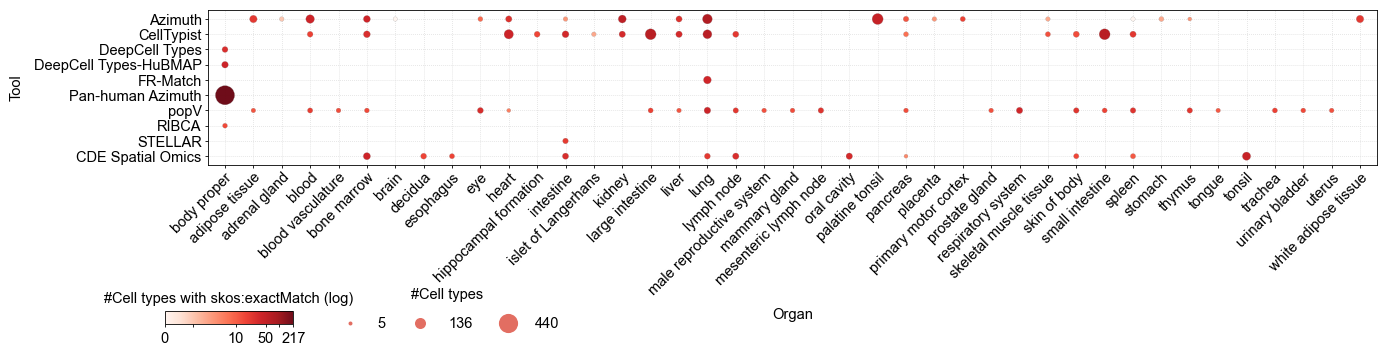

In [13]:
# Step 3: Create and save the figure.

bottom_margin_mm = (
    ORIGINAL_FIGURE_HEIGHT_MM * ORIGINAL_BOTTOM_FRACTION * BOTTOM_SPACE_SCALE
    + BOTTOM_LEGEND_SPACE_MM
)
top_margin_mm = ORIGINAL_FIGURE_HEIGHT_MM * (1 - ORIGINAL_TOP_FRACTION)
original_panel_height_mm = ORIGINAL_FIGURE_HEIGHT_MM * (ORIGINAL_TOP_FRACTION - ORIGINAL_BOTTOM_FRACTION)
panel_height_mm = original_panel_height_mm * ROW_SPACING_SCALE
figure_height_mm = bottom_margin_mm + panel_height_mm + top_margin_mm

figure_size = (
    FIGURE_WIDTH_MM * MM_TO_INCH,
    figure_height_mm * MM_TO_INCH,
)

print(f"Preparing figure, height={figure_height_mm:.2f} mm")
fig, ax = plt.subplots(figsize=figure_size)

exact_match_values = df_plot["n_exact_match_cell_labels"].astype(float)
exact_match_max = float(exact_match_values.max())
# Symmetric-log scaling preserves zero-exact-match nodes while expanding low nonzero counts.
norm = mpl.colors.SymLogNorm(
    linthresh=1,
    linscale=0.6,
    vmin=0,
    vmax=max(exact_match_max, 1),
)
cmap = plt.cm.Reds
scatter = ax.scatter(
    df_plot["organ_label"].map(x_position),
    df_plot["source"].astype(str).map(y_position),
    s=marker_area(df_plot["n_unique_cell_label"]),
    c=df_plot["n_exact_match_cell_labels"],
    cmap=cmap,
    norm=norm,
    alpha=0.95,
    linewidths=0.15,
    edgecolors="#8a8a8a",
)

ax.set_xticks(np.arange(len(organ_order)))
ax.set_xticklabels(
    organ_order,
    rotation=45,
    ha="right",
    va="top",
    fontsize=FIGURE_FONT_SIZE,
    fontfamily="sans-serif",
    rotation_mode="anchor",
)

ax.set_yticks(np.arange(len(tool_order)))
ax.set_yticklabels(
    tool_order,
    fontsize=FIGURE_FONT_SIZE,
    fontfamily="sans-serif",
)

ax.invert_yaxis()
ax.set_xlabel("Organ", labelpad=7)
ax.set_ylabel("Tool", labelpad=7)
ax.set_xlim(-0.6, len(organ_order) - 0.4)
ax.set_ylim(len(tool_order) - 0.4, -0.6)
ax.set_axisbelow(True)
ax.grid(True, which="major", axis="both", color="#d9d9d9", linestyle=":", linewidth=0.55)

for side in ["top", "right", "bottom", "left"]:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(0.6)

ax.tick_params(axis="x", pad=1, labelsize=FIGURE_FONT_SIZE)
ax.tick_params(axis="y", pad=2, labelsize=FIGURE_FONT_SIZE)

count_values = df_plot["n_unique_cell_label"].astype(float)
min_count = float(count_values.min())
max_count = float(count_values.max())
midpoint_target = (min_count + max_count) / 2
observed_counts = np.sort(count_values.dropna().unique())
midpoint_count = float(observed_counts[np.argmin(np.abs(observed_counts - midpoint_target))])
legend_values = [min_count, midpoint_count, max_count]
legend_handles = [
    ax.scatter([], [], s=marker_area(value), color="#d7301f", alpha=0.70, linewidths=0)
    for value in legend_values
]
legend_labels = [format_legend_value(v) for v in legend_values]

fig.subplots_adjust(
    left=0.15,
    right=0.96,
    top=1 - top_margin_mm / figure_height_mm,
    bottom=bottom_margin_mm / figure_height_mm,
)

ax_pos = ax.get_position()
cbar_width = 0.11 * ax_pos.width
cbar_height = 0.025
cbar_x = max(0.02, ax_pos.x0 - 0.03)
cbar_y = ax_pos.y0 - 0.31

cbar_ax = fig.add_axes([cbar_x, cbar_y, cbar_width, cbar_height])
cbar = fig.colorbar(scatter, cax=cbar_ax, orientation="horizontal")
# Keep only the requested low, middle, and high reference values.
exact_match_ticks = sorted({0, *(tick for tick in (10,  50) if tick < exact_match_max), exact_match_max})
cbar.set_ticks(exact_match_ticks)
cbar.ax.set_xticklabels([format_legend_value(value) for value in exact_match_ticks])
cbar.ax.set_title("#Cell types with skos:exactMatch (log)", fontsize=FIGURE_FONT_SIZE, pad=6)

legend_x = cbar_x + cbar_width + 0.025
legend_y = ax_pos.y0 - 0.335
fig.legend(
    legend_handles,
    legend_labels,
    title="#Cell types",
    loc="lower left",
    bbox_to_anchor=(legend_x, legend_y),
    bbox_transform=fig.transFigure,
    frameon=False,
    borderaxespad=0,
    labelspacing=1.0,
    handleheight=1.0,
    handletextpad=0.9,
    ncol=3,
    columnspacing=1.4,
)

plt.show()